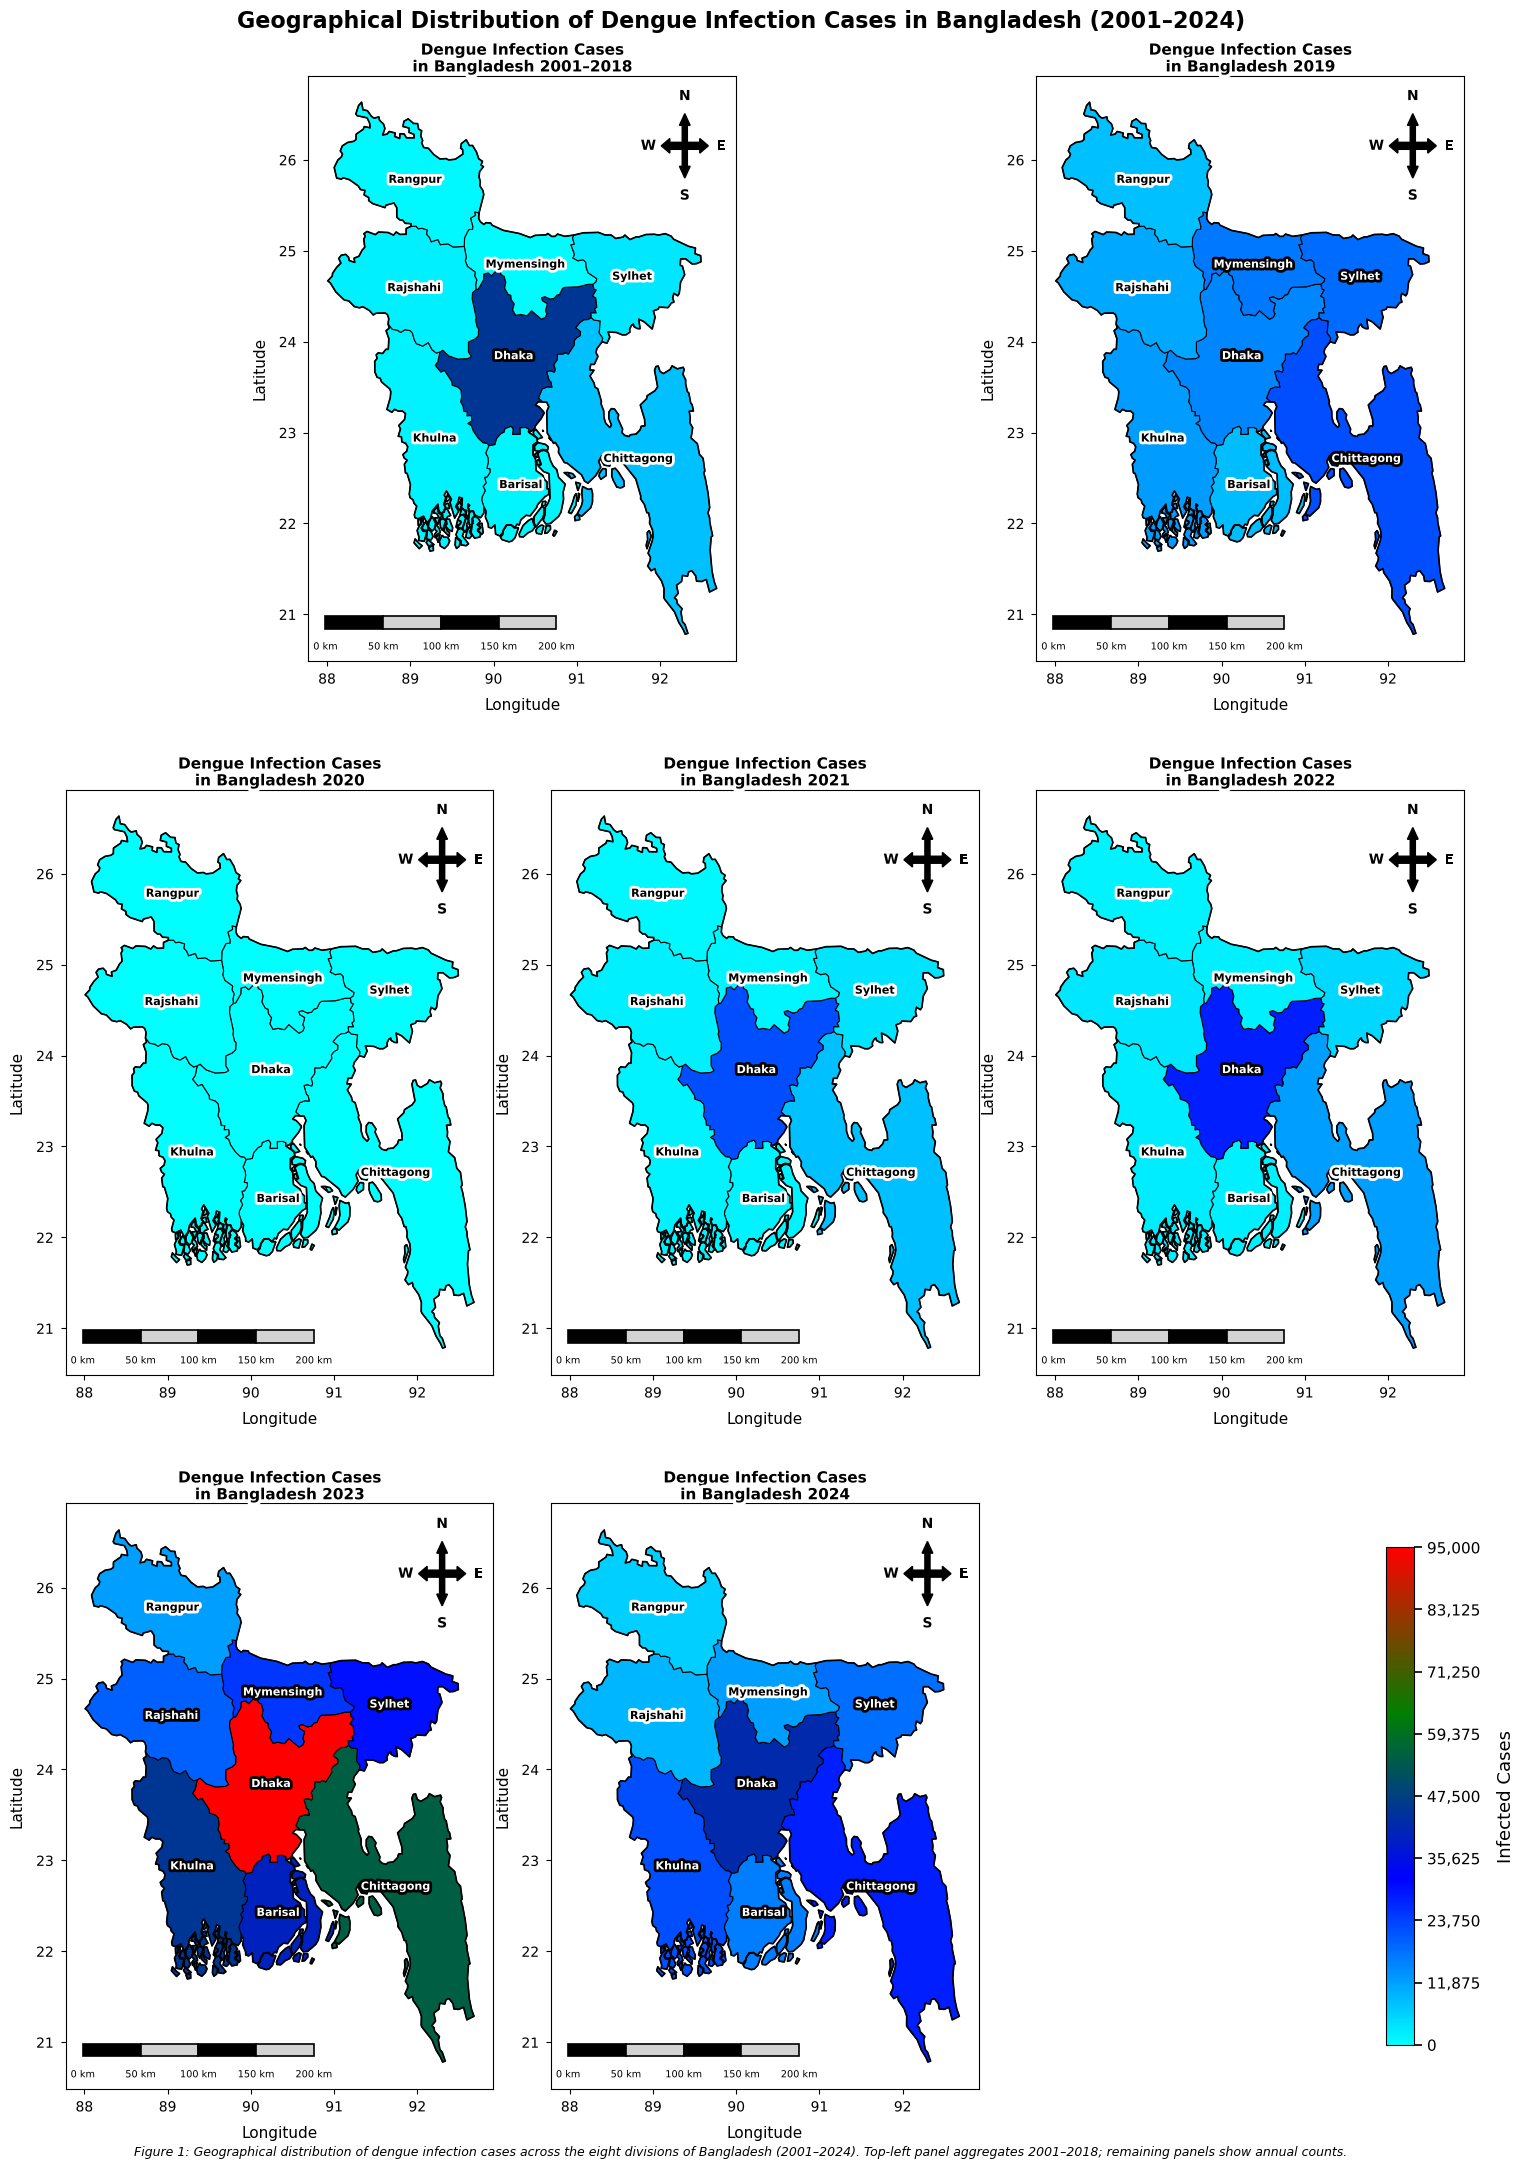

Saved: figure1_dengue_bangladesh.png


In [29]:
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.cm as cm
import matplotlib.patches as mpatches
from matplotlib.patches import FancyArrow
import matplotlib.patheffects as pe
import numpy as np
import pandas as pd

# ── White halo on text ─────────────────────────────────────────────────────────
STROKE = [pe.withStroke(linewidth=5, foreground="white")]

# ── Font sizes ─────────────────────────────────────────────────────────────────
FS_TITLE      = 11
FS_AXIS_LABEL = 11
FS_TICK       = 10
FS_DIV_LABEL  = 8
FS_COMPASS    = 10
FS_SCALE      = 7
FS_CBAR_LABEL = 13
FS_CBAR_TICK  = 11
FS_CAPTION    = 9
FS_SUPTITLE   = 16


def add_compass(ax, x=0.88, y=0.88, length=0.055):
    kw = dict(
        color="black", width=0.012, length_includes_head=True,
        head_width=0.025, head_length=0.02,
        transform=ax.transAxes, zorder=5,
    )
    ax.add_patch(FancyArrow(x, y,  0,  length, **kw))
    ax.add_patch(FancyArrow(x, y,  0, -length, **kw))
    ax.add_patch(FancyArrow(x, y,  length, 0,  **kw))
    ax.add_patch(FancyArrow(x, y, -length, 0,  **kw))
    txt_kw = dict(ha="center", va="center", fontsize=FS_COMPASS,
                  fontweight="bold", transform=ax.transAxes, zorder=6,
                  path_effects=STROKE)
    ax.text(x,                  y + length + 0.03, "N", **txt_kw)
    ax.text(x,                  y - length - 0.03, "S", **txt_kw)
    ax.text(x + length + 0.03,  y,                 "E", **txt_kw)
    ax.text(x - length - 0.03,  y,                 "W", **txt_kw)


def add_scale_bar(ax, x=0.04, y=0.055, bar_len=0.54, bar_h=0.022,
                  n_segments=4, total_km=200):
    seg    = bar_len / n_segments
    colors = ["black", "lightgray"] * (n_segments // 2 + 1)
    for i in range(n_segments):
        ax.add_patch(mpatches.Rectangle(
            (x + i * seg, y), seg, bar_h,
            facecolor=colors[i], edgecolor="black", linewidth=1.2,
            transform=ax.transAxes, zorder=5,
        ))
    km_step = total_km // n_segments
    for i in range(n_segments + 1):
        ax.text(x + i * seg, y - 0.022, f"{i * km_step} km",
                ha="center", va="top", fontsize=FS_SCALE, color="black",
                path_effects=STROKE, transform=ax.transAxes, zorder=6)


# ── Load shapefile ─────────────────────────────────────────────────────────────
shapefile_path = (
    "./geodata/"
    "small_bangladesh_geojson_adm1_8_divisions_bibhags.json"
)
gdf = gpd.read_file(shapefile_path)
gdf["division"] = gdf["ADM1_EN"].str.strip()

# ── Case data ──────────────────────────────────────────────────────────────────
data_2001_2018 = {
    "Dhaka": 45000, "Chittagong": 8000, "Sylhet": 3000,
    "Rajshahi": 2000, "Khulna": 1500, "Barisal": 1200,
    "Rangpur": 800,  "Mymensingh": 600,
}

data_yearly = {
    2019: {"Dhaka": 15000, "Chittagong": 22000, "Sylhet": 18500,
           "Rajshahi": 11000, "Khulna": 12500, "Barisal": 8500,
           "Rangpur": 7800,  "Mymensingh": 17000},
    2020: {"Dhaka": 280,   "Chittagong": 310,   "Sylhet": 220,
           "Rajshahi": 155, "Khulna": 130,  "Barisal": 125,
           "Rangpur": 105,  "Mymensingh": 245},
    2021: {"Dhaka": 22000, "Chittagong": 8000,  "Sylhet": 3500,
           "Rajshahi": 2200, "Khulna": 1800, "Barisal": 1500,
           "Rangpur": 900,  "Mymensingh": 1200},
    2022: {"Dhaka": 28000, "Chittagong": 12000, "Sylhet": 5000,
           "Rajshahi": 3000, "Khulna": 2500, "Barisal": 2000,
           "Rangpur": 1500, "Mymensingh": 2000},
    2023: {"Dhaka": 95000, "Chittagong": 55000, "Sylhet": 30000,
           "Rajshahi": 20000, "Khulna": 45000, "Barisal": 40000,
           "Rangpur": 12000, "Mymensingh": 25000},
    2024: {"Dhaka": 42000, "Chittagong": 28000, "Sylhet": 18000,
           "Rajshahi": 9000, "Khulna": 22000, "Barisal": 16000,
           "Rangpur": 6000,  "Mymensingh": 12000},
}

# ── Shared colormap & norm ─────────────────────────────────────────────────────
CMAP = mcolors.LinearSegmentedColormap.from_list(
    "RGBC", ["cyan", "blue", "green", "red"],
)
EDGE_COLOR = "black"
EDGE_WIDTH = 0.8

all_values = list(data_2001_2018.values())
for yr_data in data_yearly.values():
    all_values.extend(yr_data.values())

global_vmin = 0
global_vmax = max(all_values)        # 95,000
shared_norm = mcolors.Normalize(vmin=global_vmin, vmax=global_vmax)


def luminance(rgba):
    r, g, b = rgba[:3]
    return 0.299 * r + 0.587 * g + 0.114 * b


def plot_map(ax, gdf, case_data, title, norm):
    df     = pd.DataFrame(list(case_data.items()), columns=["division", "cases"])
    merged = gdf.merge(df, on="division", how="left")

    merged.plot(
        column="cases", cmap=CMAP, norm=norm,
        linewidth=EDGE_WIDTH, edgecolor=EDGE_COLOR,
        ax=ax, missing_kwds={"color": "lightgrey"},
    )
    gdf.dissolve().boundary.plot(ax=ax, color=EDGE_COLOR, linewidth=1.2)

    for _, row in merged.iterrows():
        if row.geometry is None:
            continue
        cx  = row.geometry.centroid.x
        cy  = row.geometry.centroid.y
        val = row.get("cases", np.nan)

        fill_rgba  = (0.827, 0.827, 0.827, 1.0) if pd.isna(val) else CMAP(norm(val))
        txt_color  = "white" if luminance(fill_rgba) < 0.45 else "black"
        stroke_col = "black" if txt_color == "white" else "white"

        ax.annotate(
            row["division"], xy=(cx, cy),
            ha="center", va="center",
            fontsize=FS_DIV_LABEL, fontweight="bold",
            color=txt_color,
            path_effects=[pe.withStroke(linewidth=4, foreground=stroke_col)],
        )

    title_wrapped = title.replace(" in Bangladesh ", "\nin Bangladesh ")
    ax.set_title(title_wrapped, fontsize=FS_TITLE, fontweight="bold",
                 pad=3, linespacing=1.15).set_path_effects(STROKE)

    ax.set_xlabel("Longitude", fontsize=FS_AXIS_LABEL, labelpad=8)
    ax.set_ylabel("Latitude",  fontsize=FS_AXIS_LABEL, labelpad=8)
    ax.tick_params(axis="x", labelsize=FS_TICK, pad=5)
    ax.tick_params(axis="y", labelsize=FS_TICK, pad=5)
    for lbl in ax.get_xticklabels() + ax.get_yticklabels():
        lbl.set_path_effects(STROKE)

    add_compass(ax)
    add_scale_bar(ax)


# ══════════════════════════════════════════════════════════════════════════════
# Figure layout  (3-column outer grid)
#
#  Row 0  │ 2001-2018  [spans cols 0-1]  │ 2019 [col 2] │
#  Row 1  │            spacer                            │
#  Row 2  │ 2020  [col 0] │ 2021 [col 1] │ 2022 [col 2] │
#  Row 3  │            spacer                            │
#  Row 4  │ 2023  [col 0] │ 2024 [col 1] │ cbar [col 2] │
# ══════════════════════════════════════════════════════════════════════════════

fig = plt.figure(figsize=(16, 22), constrained_layout=False)

outer = fig.add_gridspec(
    5, 3,
    height_ratios=[1.0, 0.22, 1.0, 0.22, 1.0],
    width_ratios=[1.0, 1.0, 1.0],
    hspace=0.0,
    wspace=0.0,
)

# ── Top row ────────────────────────────────────────────────────────────────────
ax_wide = fig.add_subplot(outer[0, 0:2])   # 2001-2018 spans 2 columns
plot_map(ax_wide, gdf, data_2001_2018,
         "Dengue Infection Cases in Bangladesh 2001–2018", shared_norm)

ax_2019 = fig.add_subplot(outer[0, 2])     # 2019 in rightmost column
plot_map(ax_2019, gdf, data_yearly[2019],
         "Dengue Infection Cases in Bangladesh 2019", shared_norm)

# ── Middle row ─────────────────────────────────────────────────────────────────
for i, year in enumerate([2020, 2021, 2022]):
    ax = fig.add_subplot(outer[2, i])
    plot_map(ax, gdf, data_yearly[year],
             f"Dengue Infection Cases in Bangladesh {year}", shared_norm)

# ── Bottom row ─────────────────────────────────────────────────────────────────
for i, year in enumerate([2023, 2024]):
    ax = fig.add_subplot(outer[4, i])
    plot_map(ax, gdf, data_yearly[year],
             f"Dengue Infection Cases in Bangladesh {year}", shared_norm)

# ── Colorbar ───────────────────────────────────────────────────────────────────
ax_cbar_host = fig.add_subplot(outer[4, 2])
ax_cbar_host.set_axis_off()

sm = cm.ScalarMappable(cmap=CMAP, norm=shared_norm)
sm.set_array([])

cbar = fig.colorbar(sm, ax=ax_cbar_host,
                    fraction=0.22, pad=0.04, aspect=18, shrink=0.85)

bounds    = np.linspace(global_vmin, global_vmax, 5)
mids      = (bounds[:-1] + bounds[1:]) / 2
all_ticks = np.unique(np.concatenate([bounds, mids]))
all_ticks = all_ticks[(all_ticks >= global_vmin) & (all_ticks <= global_vmax)]

cbar.set_ticks(all_ticks)
cbar.set_ticklabels([f"{int(t):,}" for t in all_ticks])
cbar.set_label("Infected Cases", fontsize=FS_CBAR_LABEL, labelpad=12)
cbar.ax.tick_params(labelsize=FS_CBAR_TICK, length=6, width=1.2)
for lbl in cbar.ax.get_yticklabels():
    lbl.set_path_effects(STROKE)

# ── Main title ─────────────────────────────────────────────────────────────────
fig.suptitle(
    "Geographical Distribution of Dengue Infection Cases in Bangladesh (2001–2024)",
    fontsize=FS_SUPTITLE, fontweight="bold", y=0.995,
)

# ── Global margins ─────────────────────────────────────────────────────────────
fig.subplots_adjust(
    left=0.06, right=0.97,
    top=0.965, bottom=0.050,
    hspace=0.45, wspace=0.18,
)

# ── Caption ────────────────────────────────────────────────────────────────────
caption = (
    "Figure 1: Geographical distribution of dengue infection cases across "
    "the eight divisions of Bangladesh (2001–2024). "
    "Top-left panel aggregates 2001–2018; remaining panels show annual counts."
)
fig.text(0.5, 0.018, caption,
         ha="center", va="bottom",
         fontsize=FS_CAPTION, style="italic")

# ── Save ───────────────────────────────────────────────────────────────────────
plt.savefig("figure1_dengue_bangladesh.png", dpi=300, bbox_inches="tight")
plt.show()
print("Saved: figure1_dengue_bangladesh.png")

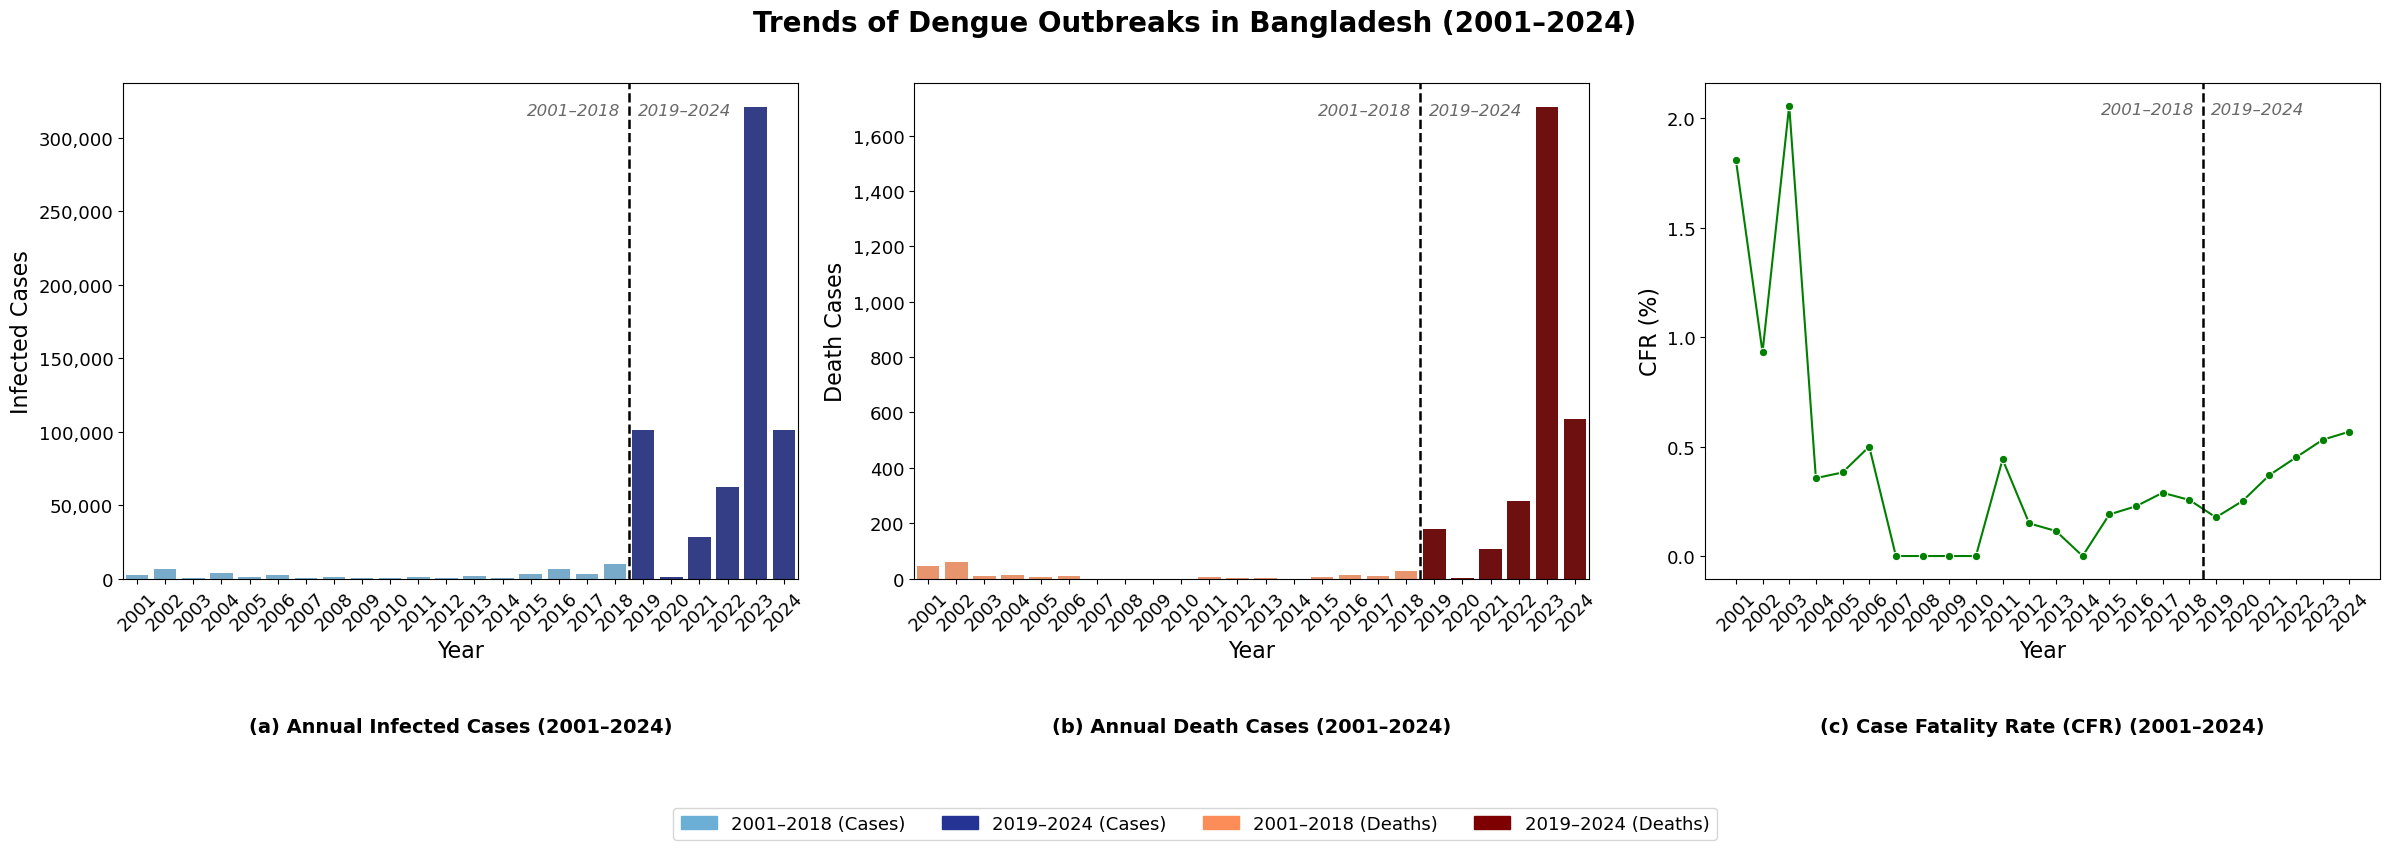

Saved: figure2_dengue_trends.png


In [18]:
"""
Figure 2: Trend of DENV outbreaks in Bangladesh (2001–2024)
"""

import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.patches as mpatches
import pandas as pd
import numpy as np

# ── Load data ──────────────────────────────────────────────────────────
data = pd.read_excel("./data/Dengue_2001-2024.xlsx")

# ── Split into periods ─────────────────────────────────────────────────
data_epidemic = data[data["Year"] <= 2018].copy()
data_endemic = data[data["Year"] > 2018].copy()

data_epidemic["CFR"] = (data_epidemic["Death"] / data_epidemic["Infected"]) * 100
data_endemic["CFR"] = (data_endemic["Death"] / data_endemic["Infected"]) * 100

# ── Merge both periods ─────────────────────────────────────────────────
df_epidemic = data_epidemic.reset_index(drop=True).copy()
df_endemic = data_endemic.reset_index(drop=True).copy()

df_epidemic["Period"] = "2001-2018"
df_endemic["Period"] = "2019-2024"

df_all = pd.concat([df_epidemic, df_endemic], ignore_index=True)
df_all["Year"] = df_all["Year"].astype(int).astype(str)

sorted_years = sorted(df_all["Year"].unique(), key=lambda y: int(y))
n_epidemic = len(df_epidemic)

# ── Colour palettes ────────────────────────────────────────────────────
palette_infected = {
    yr: ("#6baed6" if int(yr) <= 2018 else "#253494")
    for yr in sorted_years
}

palette_deaths = {
    yr: ("#fc8d59" if int(yr) <= 2018 else "#7f0000")
    for yr in sorted_years
}

# ── Figure layout ──────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(24, 8))  # wider + taller

# ── Panel 1: Infected Cases ────────────────────────────────────────────
sns.barplot(
    data=df_all,
    x="Year",
    y="Infected",
    hue="Year",
    palette=palette_infected,
    order=sorted_years,
    legend=False,
    ax=axes[0],
)

axes[0].set_xlabel("Year", fontsize=16)
axes[0].set_ylabel("Infected Cases", fontsize=16)
axes[0].tick_params(axis="x", rotation=45, labelsize=13)
axes[0].tick_params(axis="y", labelsize=13)
axes[0].yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda v, _: f"{int(v):,}")
)

# ── Panel 2: Death Cases ───────────────────────────────────────────────
sns.barplot(
    data=df_all,
    x="Year",
    y="Death",
    hue="Year",
    palette=palette_deaths,
    order=sorted_years,
    legend=False,
    ax=axes[1],
)

axes[1].set_xlabel("Year", fontsize=16)
axes[1].set_ylabel("Death Cases", fontsize=16)
axes[1].tick_params(axis="x", rotation=45, labelsize=13)
axes[1].tick_params(axis="y", labelsize=13)
axes[1].yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda v, _: f"{int(v):,}")
)

# ── Panel 3: CFR ───────────────────────────────────────────────────────
sns.lineplot(
    data=df_all,
    x="Year",
    y="CFR",
    marker="o",
    color="green",
    ax=axes[2],
)

axes[2].set_xlabel("Year", fontsize=16)
axes[2].set_ylabel("CFR (%)", fontsize=16)
axes[2].tick_params(axis="x", rotation=45, labelsize=13)
axes[2].tick_params(axis="y", labelsize=13)

# ── Divider line between periods ───────────────────────────────────────
divider_pos = n_epidemic - 0.5

for ax in axes:
    ymin, ymax = ax.get_ylim()

    ax.axvline(
        x=divider_pos,
        color="black",
        linewidth=1.8,
        linestyle="--",
        zorder=5,
    )

    ax.text(
        divider_pos - 0.3,
        ymax * 0.96,
        "2001–2018",
        ha="right",
        va="top",
        fontsize=12,        # up from 9
        color="dimgray",
        style="italic",
    )

    ax.text(
        divider_pos + 0.3,
        ymax * 0.96,
        "2019–2024",
        ha="left",
        va="top",
        fontsize=12,        # up from 9
        color="dimgray",
        style="italic",
    )

# ── Subcaptions ────────────────────────────────────────────────────────
subcaptions = [
    "(a) Annual Infected Cases (2001–2024)",
    "(b) Annual Death Cases (2001–2024)",
    "(c) Case Fatality Rate (CFR) (2001–2024)",
]

for ax, label in zip(axes, subcaptions):
    ax.text(
        0.5,
        -0.28,              # slightly lower to avoid overlap
        label,
        transform=ax.transAxes,
        ha="center",
        va="top",
        fontsize=14,        # up from 12
        fontweight="bold",
    )

# ── Legend ─────────────────────────────────────────────────────────────
legend_handles = [
    mpatches.Patch(color="#6baed6", label="2001–2018 (Cases)"),
    mpatches.Patch(color="#253494", label="2019–2024 (Cases)"),
    mpatches.Patch(color="#fc8d59", label="2001–2018 (Deaths)"),
    mpatches.Patch(color="#7f0000", label="2019–2024 (Deaths)"),
]

fig.legend(
    handles=legend_handles,
    loc="lower center",
    ncol=4,
    fontsize=13,            # up from 10
    bbox_to_anchor=(0.5, -0.03),
    frameon=True,
)

# ── Main title ─────────────────────────────────────────────────────────
fig.suptitle(
    "Trends of Dengue Outbreaks in Bangladesh (2001–2024)",
    fontsize=20,            # up from 16
    fontweight="bold",
    y=1.02,
)

# ── Caption ────────────────────────────────────────────────────────────
caption = ""

fig.text(
    0.5,
    -0.08,
    caption,
    ha="center",
    va="top",
    fontsize=12,            # up from 9
    style="italic",
    wrap=True,
)

# ── Layout adjustment ──────────────────────────────────────────────────
plt.tight_layout(rect=[0, 0.05, 1, 1])

# ── Save figure ────────────────────────────────────────────────────────
plt.savefig(
    "figure2_dengue_trends.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()
print("Saved: figure2_dengue_trends.png")

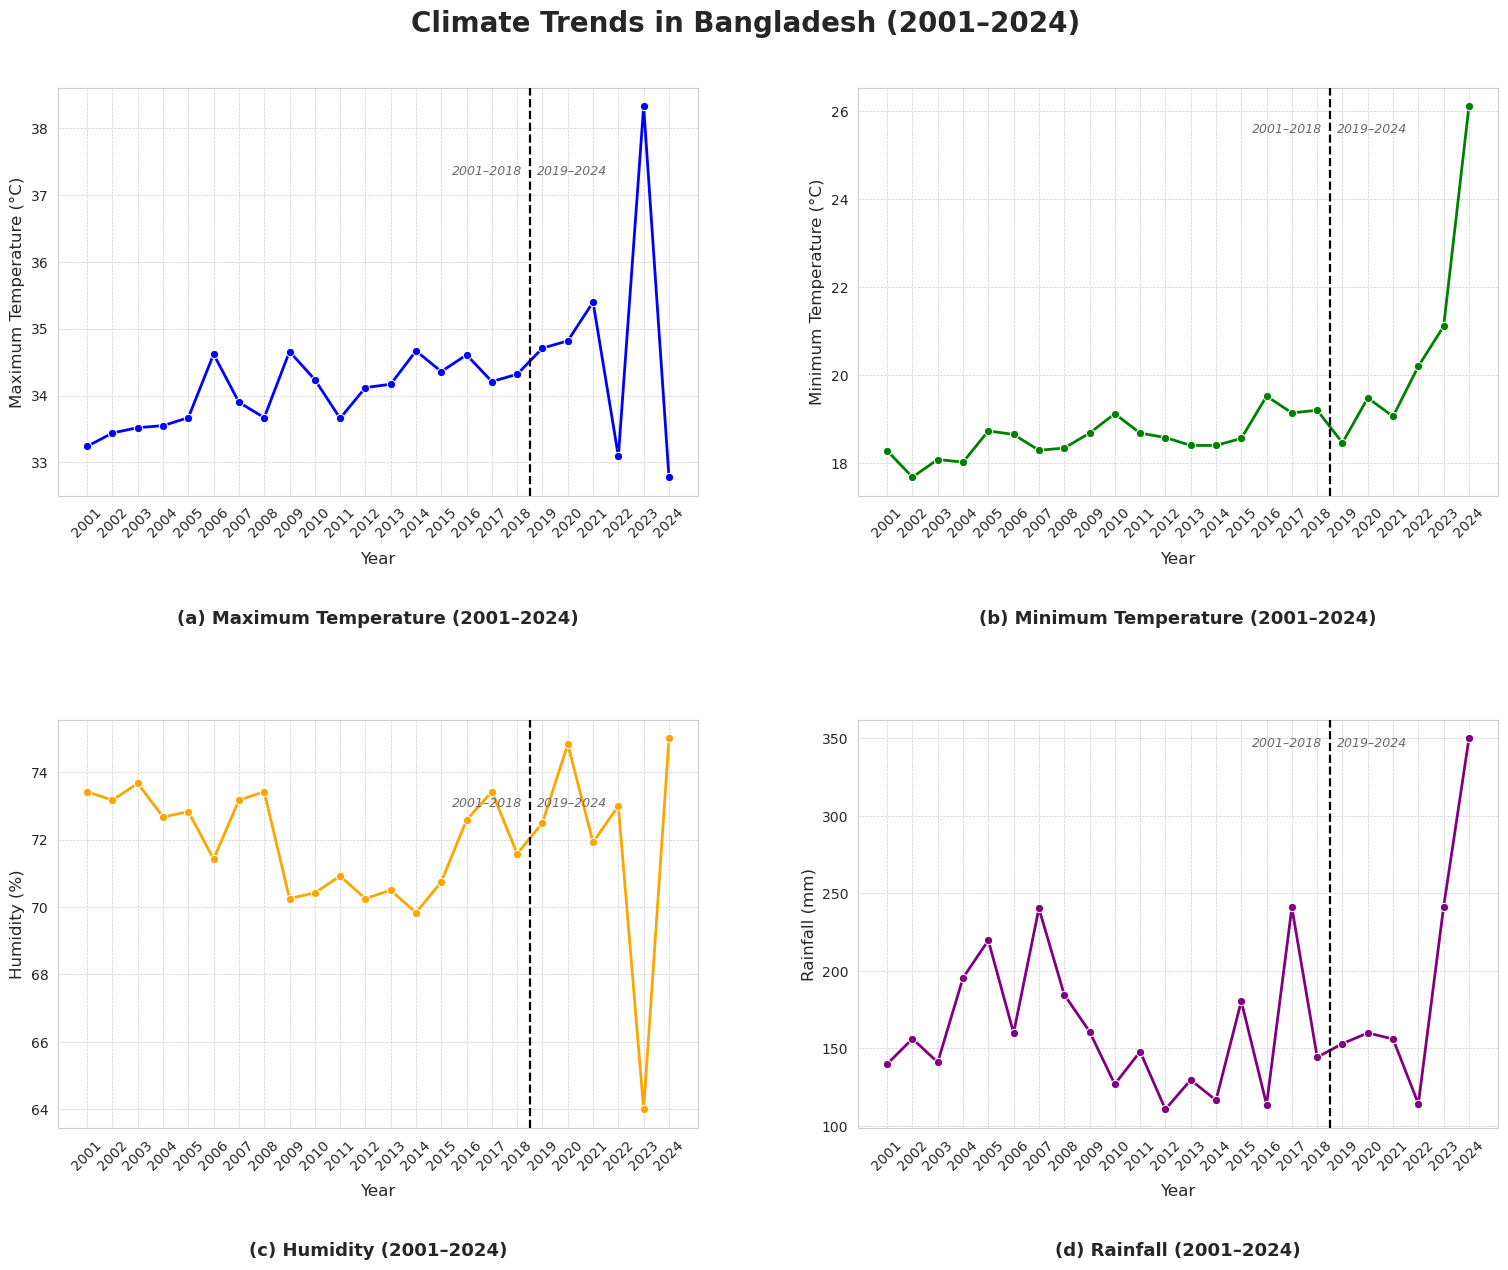

Saved: figure3_climate_trends_fixed.png


In [30]:
"""
Figure 3: Climate trends in Bangladesh (2001–2024)

Panels:
  (a) Maximum Temperature
  (b) Minimum Temperature
  (c) Humidity
  (d) Rainfall

Subcaptions appear below each subplot while retaining x-axis labels.
Spacing is adjusted to prevent overlap.
"""

import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

sns.set_style("whitegrid")

# ── Load data ──────────────────────────────────────────────────────────
data = pd.read_excel("./data/Dengue_2001-2024.xlsx")

# ── Split periods ──────────────────────────────────────────────────────
data_epidemic = data[data["Year"] <= 2018].copy()
data_endemic  = data[data["Year"] > 2018].copy()

df_epidemic = data_epidemic.reset_index(drop=True)
df_endemic  = data_endemic.reset_index(drop=True)

df_epidemic["Period"] = "2001–2018"
df_endemic["Period"]  = "2019–2024"

df_all = pd.concat([df_epidemic, df_endemic], ignore_index=True)
df_all["Year"] = df_all["Year"].astype(int).astype(str)

sorted_years  = sorted(df_all["Year"].unique(), key=lambda y: int(y))
n_epidemic    = len(df_epidemic)
divider_pos   = n_epidemic - 0.5


# ── Helper for vertical divider ────────────────────────────────────────
def add_divider(ax):
    ymin, ymax = ax.get_ylim()

    ax.axvline(
        x=divider_pos,
        color="black",
        linewidth=1.6,
        linestyle="--",
        zorder=5,
    )
    ax.text(
        divider_pos - 0.3, ymax * 0.97,
        "2001–2018",
        ha="right", va="top",
        fontsize=9, color="dimgray", style="italic",
    )
    ax.text(
        divider_pos + 0.3, ymax * 0.97,
        "2019–2024",
        ha="left", va="top",
        fontsize=9, color="dimgray", style="italic",
    )


# ── Figure ─────────────────────────────────────────────────────────────
# Use constrained_layout=False so we control spacing manually
fig, axes = plt.subplots(2, 2, figsize=(16, 13), constrained_layout=False)

fig.suptitle(
    "Climate Trends in Bangladesh (2001–2024)",
    fontsize=20,
    fontweight="bold",
    y=0.98,
)

# ── Panel (a) Maximum Temperature ─────────────────────────────────────
sns.lineplot(
    data=df_all, x="Year", y="Tmax",
    marker="o", linewidth=2, color="blue",
    ax=axes[0, 0],
)
axes[0, 0].set_xlabel("Year", fontsize=12, labelpad=8)
axes[0, 0].set_ylabel("Maximum Temperature (°C)", fontsize=12)
axes[0, 0].tick_params(axis="x", rotation=45, labelsize=10)
axes[0, 0].tick_params(axis="y", labelsize=10)
axes[0, 0].grid(True, linestyle="--", linewidth=0.5)
add_divider(axes[0, 0])

# ── Panel (b) Minimum Temperature ─────────────────────────────────────
sns.lineplot(
    data=df_all, x="Year", y="Tmin",
    marker="o", linewidth=2, color="green",
    ax=axes[0, 1],
)
axes[0, 1].set_xlabel("Year", fontsize=12, labelpad=8)
axes[0, 1].set_ylabel("Minimum Temperature (°C)", fontsize=12)
axes[0, 1].tick_params(axis="x", rotation=45, labelsize=10)
axes[0, 1].tick_params(axis="y", labelsize=10)
axes[0, 1].grid(True, linestyle="--", linewidth=0.5)
add_divider(axes[0, 1])

# ── Panel (c) Humidity ─────────────────────────────────────────────────
sns.lineplot(
    data=df_all, x="Year", y="Relative Humidity",
    marker="o", linewidth=2, color="orange",
    ax=axes[1, 0],
)
axes[1, 0].set_xlabel("Year", fontsize=12, labelpad=8)
axes[1, 0].set_ylabel("Humidity (%)", fontsize=12)
axes[1, 0].tick_params(axis="x", rotation=45, labelsize=10)
axes[1, 0].tick_params(axis="y", labelsize=10)
axes[1, 0].grid(True, linestyle="--", linewidth=0.5)
add_divider(axes[1, 0])

# ── Panel (d) Rainfall ─────────────────────────────────────────────────
sns.lineplot(
    data=df_all, x="Year", y="Rainfall",
    marker="o", linewidth=2, color="purple",
    ax=axes[1, 1],
)
axes[1, 1].set_xlabel("Year", fontsize=12, labelpad=8)
axes[1, 1].set_ylabel("Rainfall (mm)", fontsize=12)
axes[1, 1].tick_params(axis="x", rotation=45, labelsize=10)
axes[1, 1].tick_params(axis="y", labelsize=10)
axes[1, 1].grid(True, linestyle="--", linewidth=0.5)
add_divider(axes[1, 1])

# ── Subcaptions (placed low enough to clear rotated tick labels) ───────
subcaptions = [
    "(a) Maximum Temperature (2001–2024)",
    "(b) Minimum Temperature (2001–2024)",
    "(c) Humidity (2001–2024)",
    "(d) Rainfall (2001–2024)",
]

for ax, label in zip(axes.flat, subcaptions):
    ax.text(
        0.5, -0.28,          # pushed further below to clear rotated ticks
        label,
        transform=ax.transAxes,
        ha="center", va="top",
        fontsize=13, fontweight="bold",
    )

# ── Spacing — do NOT mix tight_layout with subplots_adjust ─────────────
fig.subplots_adjust(
    left=0.07,
    right=0.97,
    top=0.92,     # room for suptitle
    bottom=0.12,  # room for bottom subcaptions
    hspace=0.55,  # generous vertical gap (ticks + subcaption)
    wspace=0.25,  # horizontal gap
)

# ── Save ───────────────────────────────────────────────────────────────
plt.savefig(
    "figure3_climate_trends_fixed.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()
print("Saved: figure3_climate_trends_fixed.png")

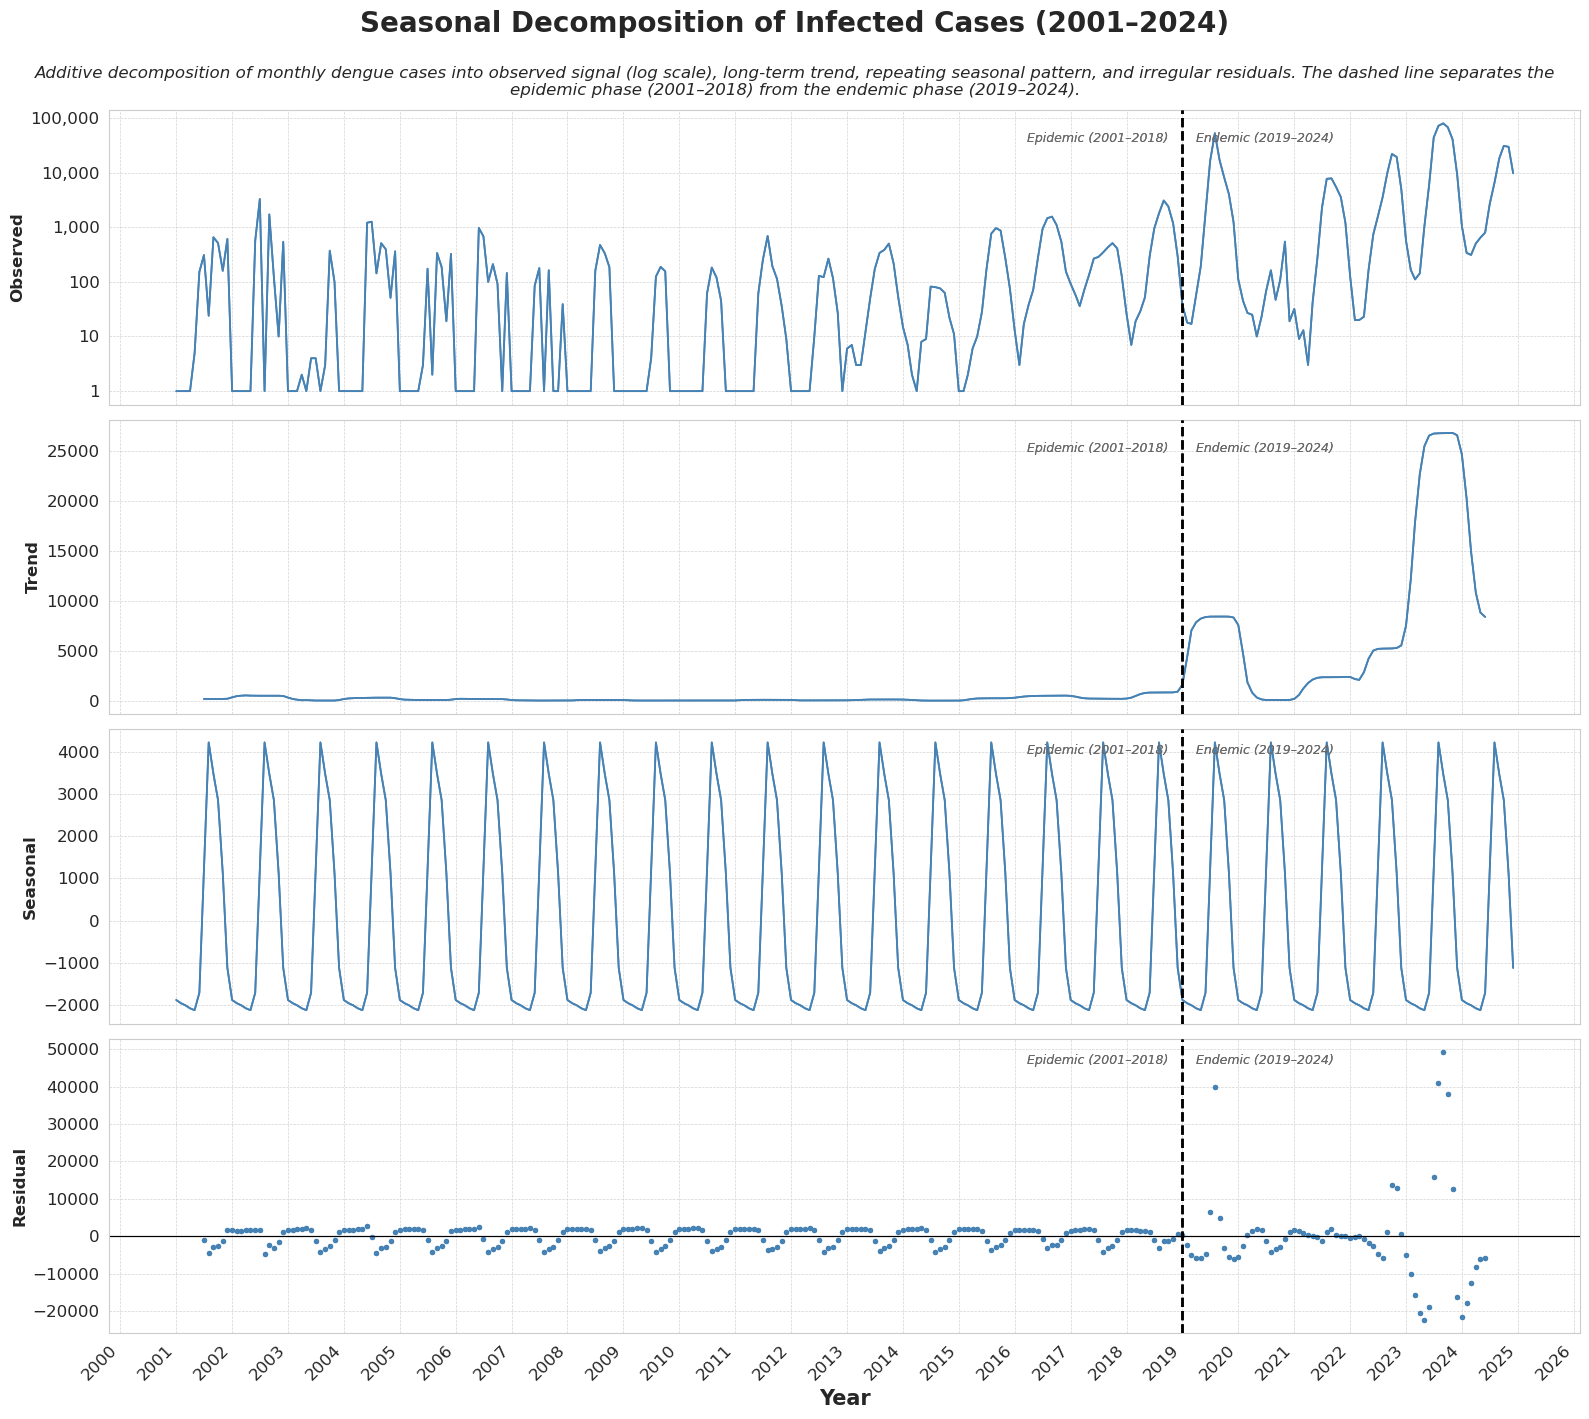

Saved: figure4_seasonal_decomposition.png


In [34]:
"""
Figure 4: Seasonal Decomposition of infected cases (2001–2024)

4 panels (Observed, Trend, Seasonal, Residual) each spanning the full
2001–2024 timeline on a shared y-axis. A vertical dashed line at Jan 2019
separates the epidemic (2001–2018) and endemic (2019–2024) periods.
Observed panel uses log scale.
"""

import pandas as pd
from statsmodels.tsa.seasonal import seasonal_decompose
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.dates as mdates
import numpy as np

# ── Load and reshape ───────────────────────────────────────────────────────────
file_path = "./data/Monthly_Infection_2001-2024.xlsx"
data = pd.read_excel(file_path)

data_long = data.melt(
    id_vars=['Year'],
    value_vars=['January','February','March','April','May','June',
                'July','August','September','October','November','December'],
    var_name='Month', value_name='Cases'
)
month_map = {'January':1,'February':2,'March':3,'April':4,'May':5,'June':6,
             'July':7,'August':8,'September':9,'October':10,'November':11,'December':12}
data_long['Month'] = data_long['Month'].map(month_map)
data_long['Date']  = pd.to_datetime(data_long[['Year','Month']].assign(Day=1))
data_long.sort_values('Date', inplace=True)
data_long = data_long.set_index('Date')

# ── Decompose full series ──────────────────────────────────────────────────────
decomp = seasonal_decompose(data_long['Cases'], model='additive', period=12)

# Divider date
divider = pd.Timestamp('2019-01-01')

# ── Figure ─────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(4, 1, figsize=(16, 14), sharex=True)

fig.suptitle(
    "Seasonal Decomposition of Infected Cases (2001–2024)",
    fontsize=20, fontweight='bold', y=1.01
)
fig.text(
    0.5, 0.97,
    "Additive decomposition of monthly dengue cases into observed signal (log scale), "
    "long-term trend, repeating seasonal pattern, and irregular residuals. "
    "The dashed line separates the epidemic phase (2001–2018) from the endemic phase (2019–2024).",
    ha='center', va='top', fontsize=12, style='italic', wrap=True
)

components = [
    ('Observed',  decomp.observed,  'log',    'steelblue', False),
    ('Trend',     decomp.trend,     'linear', 'steelblue', False),
    ('Seasonal',  decomp.seasonal,  'linear', 'steelblue', False),
    ('Residual',  decomp.resid,     'linear', 'steelblue', True),
]

# Make y-axis label bold for each panel
for ax, (label, series, scale, color, is_resid) in zip(axes, components):
    if is_resid:
        ax.scatter(series.index, series.values, s=8, color=color, zorder=2)
        ax.axhline(0, color='black', linewidth=0.8)
    else:
        # For log scale, clip to 1 to avoid log(0)
        plot_series = series.clip(lower=1) if scale == 'log' else series
        ax.plot(plot_series.index, plot_series.values,
                color=color, linewidth=1.3)

    if scale == 'log':
        ax.set_yscale('log')
        ax.yaxis.set_major_formatter(
            mticker.FuncFormatter(lambda v, _: f"{int(v):,}")
        )

    # Vertical divider
    ax.axvline(x=divider, color='black', linewidth=1.8,
               linestyle='--', zorder=5)

    # Period labels
    ymin, ymax = ax.get_ylim()
    y_pos = ymax * 0.92 if scale != 'log' else 10 ** (0.92 * np.log10(max(ymax, 1)))
    ax.text(divider - pd.DateOffset(months=3), y_pos,
            "Epidemic (2001–2018)",
            ha='right', va='top', fontsize=9, color='dimgray', style='italic')
    ax.text(divider + pd.DateOffset(months=3), y_pos,
            "Endemic (2019–2024)",
            ha='left', va='top', fontsize=9, color='dimgray', style='italic')

    # Set bold y-axis label
    ax.set_ylabel(label, fontsize=12, fontweight='bold')
    ax.grid(color='lightgray', linestyle='--', linewidth=0.5)
    ax.tick_params(axis='both', labelsize=12)

for ax, (label, series, scale, color, is_resid) in zip(axes, components):
    if is_resid:
        ax.scatter(series.index, series.values, s=8, color=color, zorder=2)
        ax.axhline(0, color='black', linewidth=0.8)
    else:
        # For log scale, clip to 1 to avoid log(0)
        plot_series = series.clip(lower=1) if scale == 'log' else series
        ax.plot(plot_series.index, plot_series.values,
                color=color, linewidth=1.3)

    if scale == 'log':
        ax.set_yscale('log')
        ax.yaxis.set_major_formatter(
            mticker.FuncFormatter(lambda v, _: f"{int(v):,}")
        )

    # Vertical divider
    ax.axvline(x=divider, color='black', linewidth=1.8,
               linestyle='--', zorder=5)

    # Period labels
    ymin, ymax = ax.get_ylim()
    y_pos = ymax * 0.92 if scale != 'log' else 10 ** (0.92 * np.log10(max(ymax, 1)))
    ax.text(divider - pd.DateOffset(months=3), y_pos,
            "Epidemic (2001–2018)",
            ha='right', va='top', fontsize=9, color='dimgray', style='italic')
    ax.text(divider + pd.DateOffset(months=3), y_pos,
            "Endemic (2019–2024)",
            ha='left', va='top', fontsize=9, color='dimgray', style='italic')

    ax.set_ylabel(label, fontsize=12)
    ax.grid(color='lightgray', linestyle='--', linewidth=0.5)
    ax.tick_params(axis='both', labelsize=12)

# X-axis formatting — integer years, no decimals
axes[-1].set_xlabel('Year', fontsize=15, weight='bold')
axes[-1].xaxis.set_major_locator(mdates.YearLocator())
axes[-1].xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.setp(axes[-1].xaxis.get_majorticklabels(), rotation=45, ha='right')

# Caption
# caption = (
#     "Figure 4: Additive seasonal decomposition of monthly dengue infection counts in Bangladesh (2001–2024). "
#     "The observed panel uses a logarithmic y-axis to enable visual comparison across the two periods. "
#     "The dashed vertical line marks the transition from epidemic (2001–2018) to endemic (2019–2024) phase."
# )
caption = ("")
fig.text(0.5, -0.02, caption, ha='center', va='top', fontsize=9,
         style='italic', wrap=True)

plt.tight_layout(rect=[0, 0, 1, 0.98])
plt.savefig("figure4_seasonal_decomposition.png", dpi=300, bbox_inches="tight")
plt.show()
print("Saved: figure4_seasonal_decomposition.png")

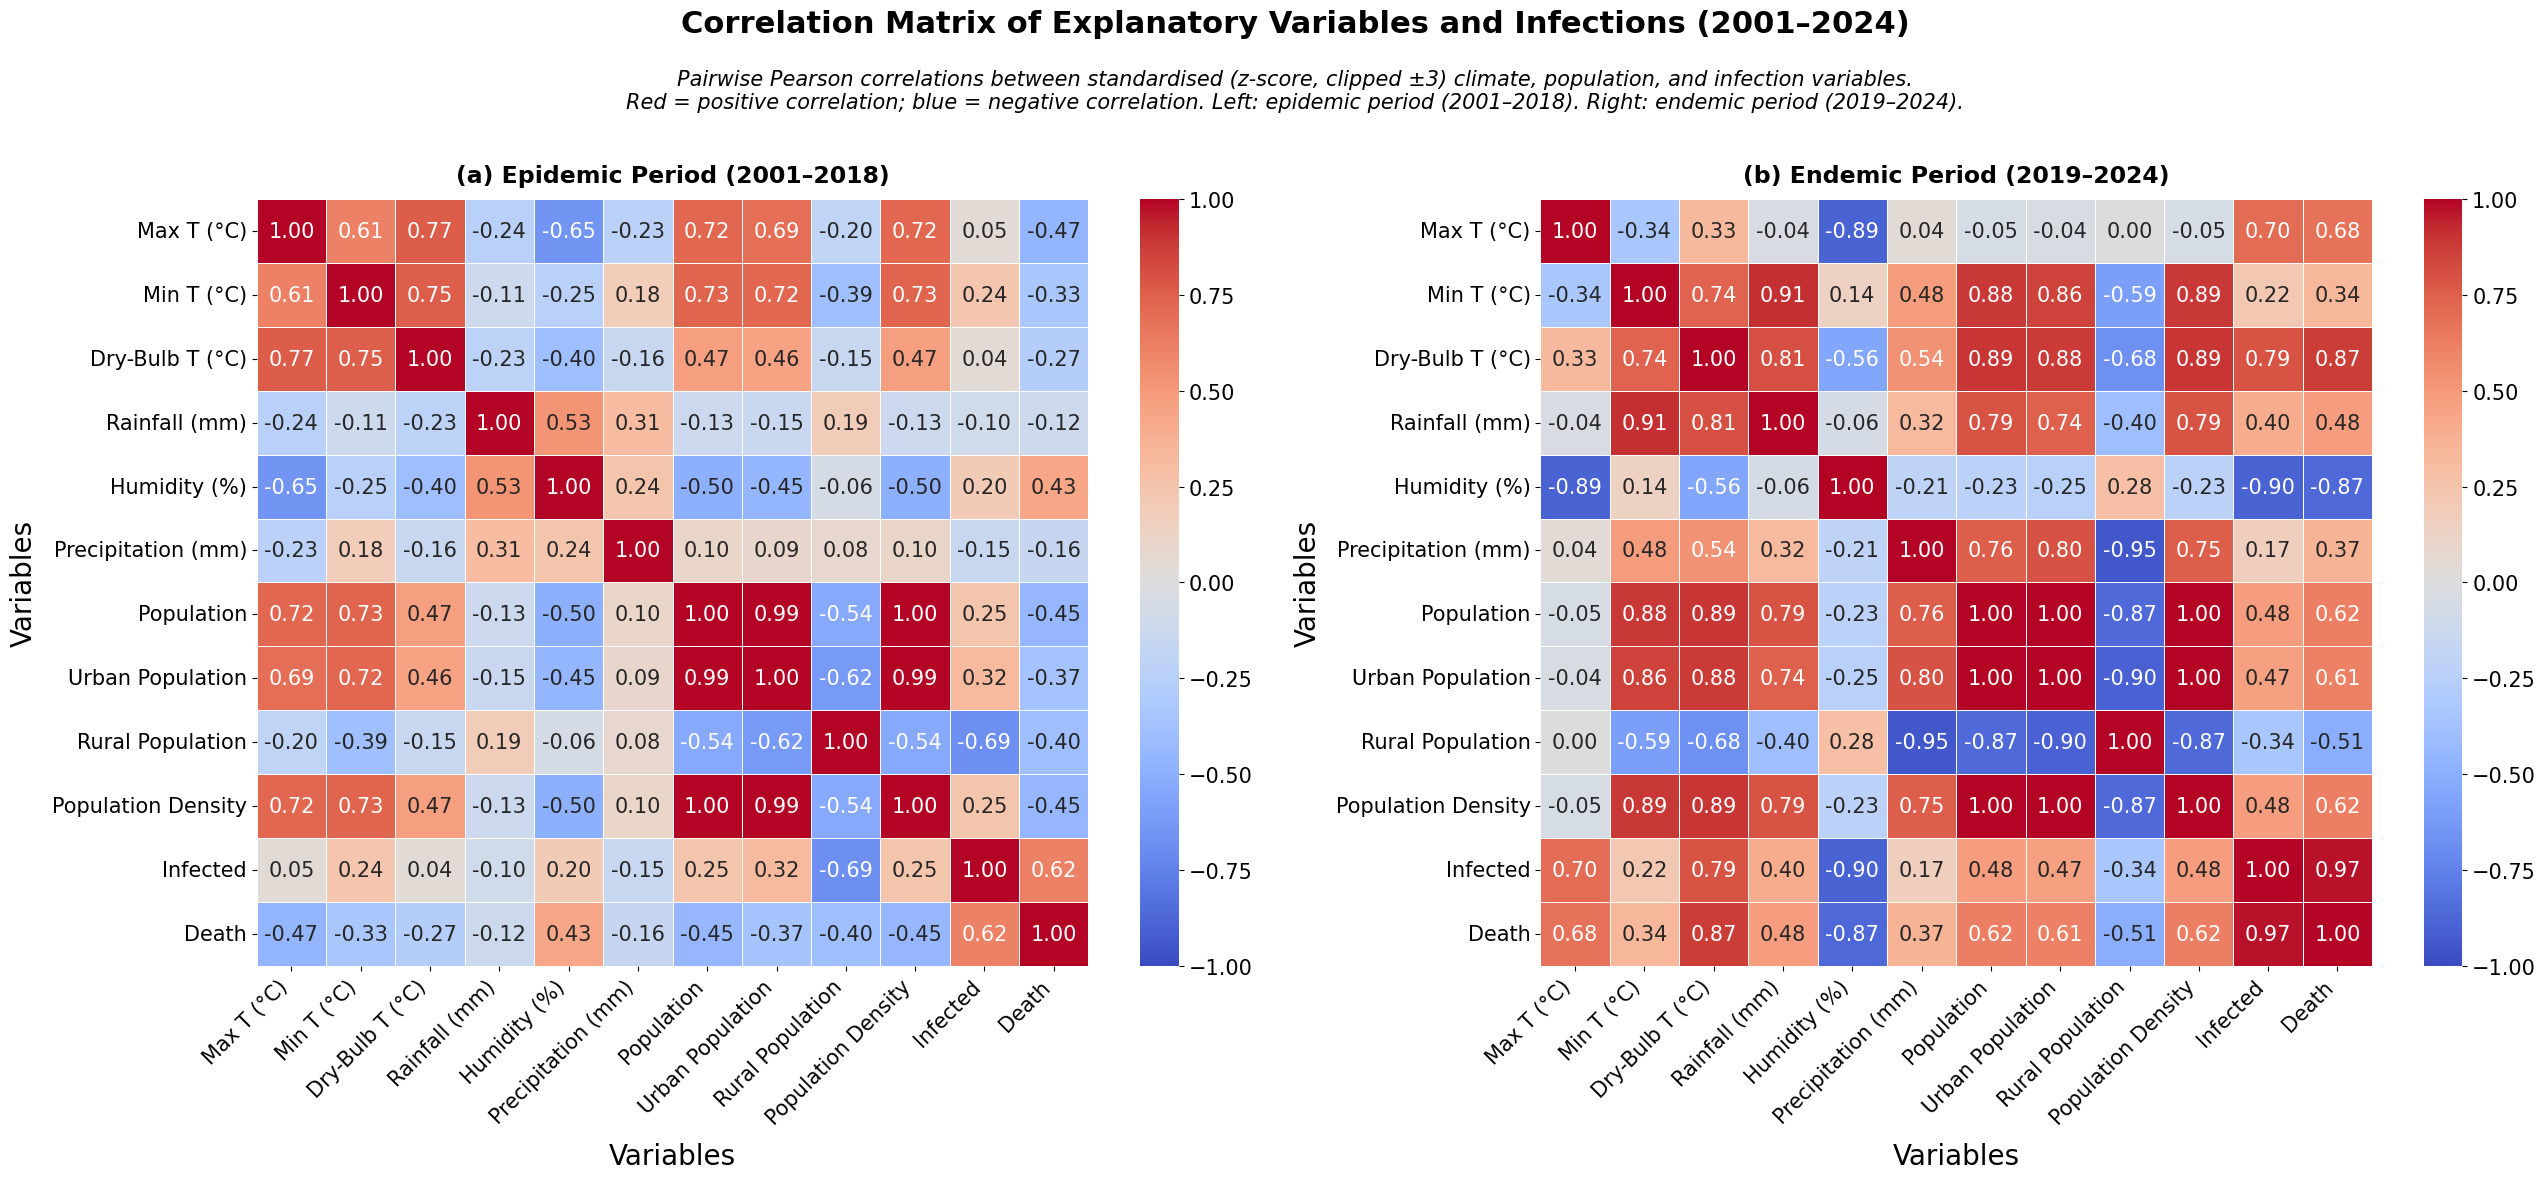

Saved: figure5_correlation_heatmap.png


In [17]:
"""
Figure 5: Correlation heatmap of explanatory variables (2001–2024)

Normalisation matches original code exactly:
  - Standardise (z-score): (x - mean) / std
  - Clip to [-3, 3]
  - Add back Infected and Death (un-normalised) for correlation

Both panels side by side, shared colorbar scale, full x and y axis labels.
"""

import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# ── Load data ──────────────────────────────────────────────────────────────────
data = pd.read_excel("./data/Dengue_2001-2024.xlsx")
data_epidemic = data[data['Year'] <= 2018].copy()
data_endemic  = data[data['Year'] >  2018].copy()

# ── Feature columns (from your original code) ─────────────────────────────────
feature_cols = [
    "Tmax", "Tmin", "Dry Bulb Temperature", "Rainfall",
    "Relative Humidity", "Precipitation",
    "Population", "UPop", "RPop", "Population Density",
]

# ── Axis label map — now includes Population ──────────────────────────────────
axis_label_map = {
    "Tmax":                 "Max T (°C)",
    "Tmin":                 "Min T (°C)",
    "Dry Bulb Temperature": "Dry-Bulb T (°C)",
    "Rainfall":             "Rainfall (mm)",
    "Relative Humidity":    "Humidity (%)",
    "Precipitation":        "Precipitation (mm)",
    "Population":           "Population",
    "UPop":                 "Urban Population",
    "RPop":                 "Rural Population",
    "Population Density":   "Population Density",
    "Infected":             "Infected",
    "Death":                "Death",
}

def make_normalized(df):
    """Standardise, clip, re-attach Infected & Death — matches your original code."""
    norm = df[feature_cols].apply(pd.to_numeric)
    norm = (norm - norm.mean()) / norm.std()   # z-score
    norm = norm.clip(lower=-3, upper=3)         # clip extremes
    norm["Infected"] = df["Infected"].values
    norm["Death"]    = df["Death"].values
    return norm

def make_corr(df):
    norm = make_normalized(df)
    corr = norm.corr()
    corr.rename(index=axis_label_map, columns=axis_label_map, inplace=True)
    return corr

corr_epidemic = make_corr(data_epidemic)
corr_endemic  = make_corr(data_endemic)

# ── Figure ─────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(26, 12))

fig.suptitle(
    "Correlation Matrix of Explanatory Variables and Infections (2001–2024)",
    fontsize=22, fontweight='bold', y=0.98
)
fig.text(
    0.5, 0.93,
    "Pairwise Pearson correlations between standardised (z-score, clipped ±3) climate, population, and infection variables.\n"
    "Red = positive correlation; blue = negative correlation. Left: epidemic period (2001–2018). Right: endemic period (2019–2024).",
    ha='center', va='top', fontsize=15, style='italic'
)

heatmap_kw = dict(
    annot=True, cmap="coolwarm", cbar=True,
    fmt=".2f", linewidths=0.5, vmin=-1, vmax=1,
    annot_kws={"size": 15},
    cbar_kws={"shrink": 1}
)

for ax, corr, title in zip(
    axes,
    [corr_epidemic, corr_endemic],
    ["(a) Epidemic Period (2001–2018)", "(b) Endemic Period (2019–2024)"]
):
    sns.heatmap(corr, ax=ax, **heatmap_kw)
    ax.collections[0].colorbar.ax.tick_params(labelsize=15)  # ← colorbar tick font size
    ax.set_title(title, fontsize=17, fontweight='bold', pad=12)
    ax.set_xlabel("Variables", fontsize=20, labelpad=10)
    ax.set_ylabel("Variables", fontsize=20, labelpad=10)
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right', fontsize=15)
    ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=15)

# ── Caption ────────────────────────────────────────────────────────────────────
caption = ("")
fig.text(
    0.5, -0.02,
    caption,
    ha='center', va='top', fontsize=13, style='italic'
)

plt.tight_layout(rect=[0, 0, 1, 0.90])  # reserve top 10% for title + subtitle
plt.savefig("figure5_correlation_heatmap.png", dpi=300, bbox_inches="tight")
plt.show()
print("Saved: figure5_correlation_heatmap.png")

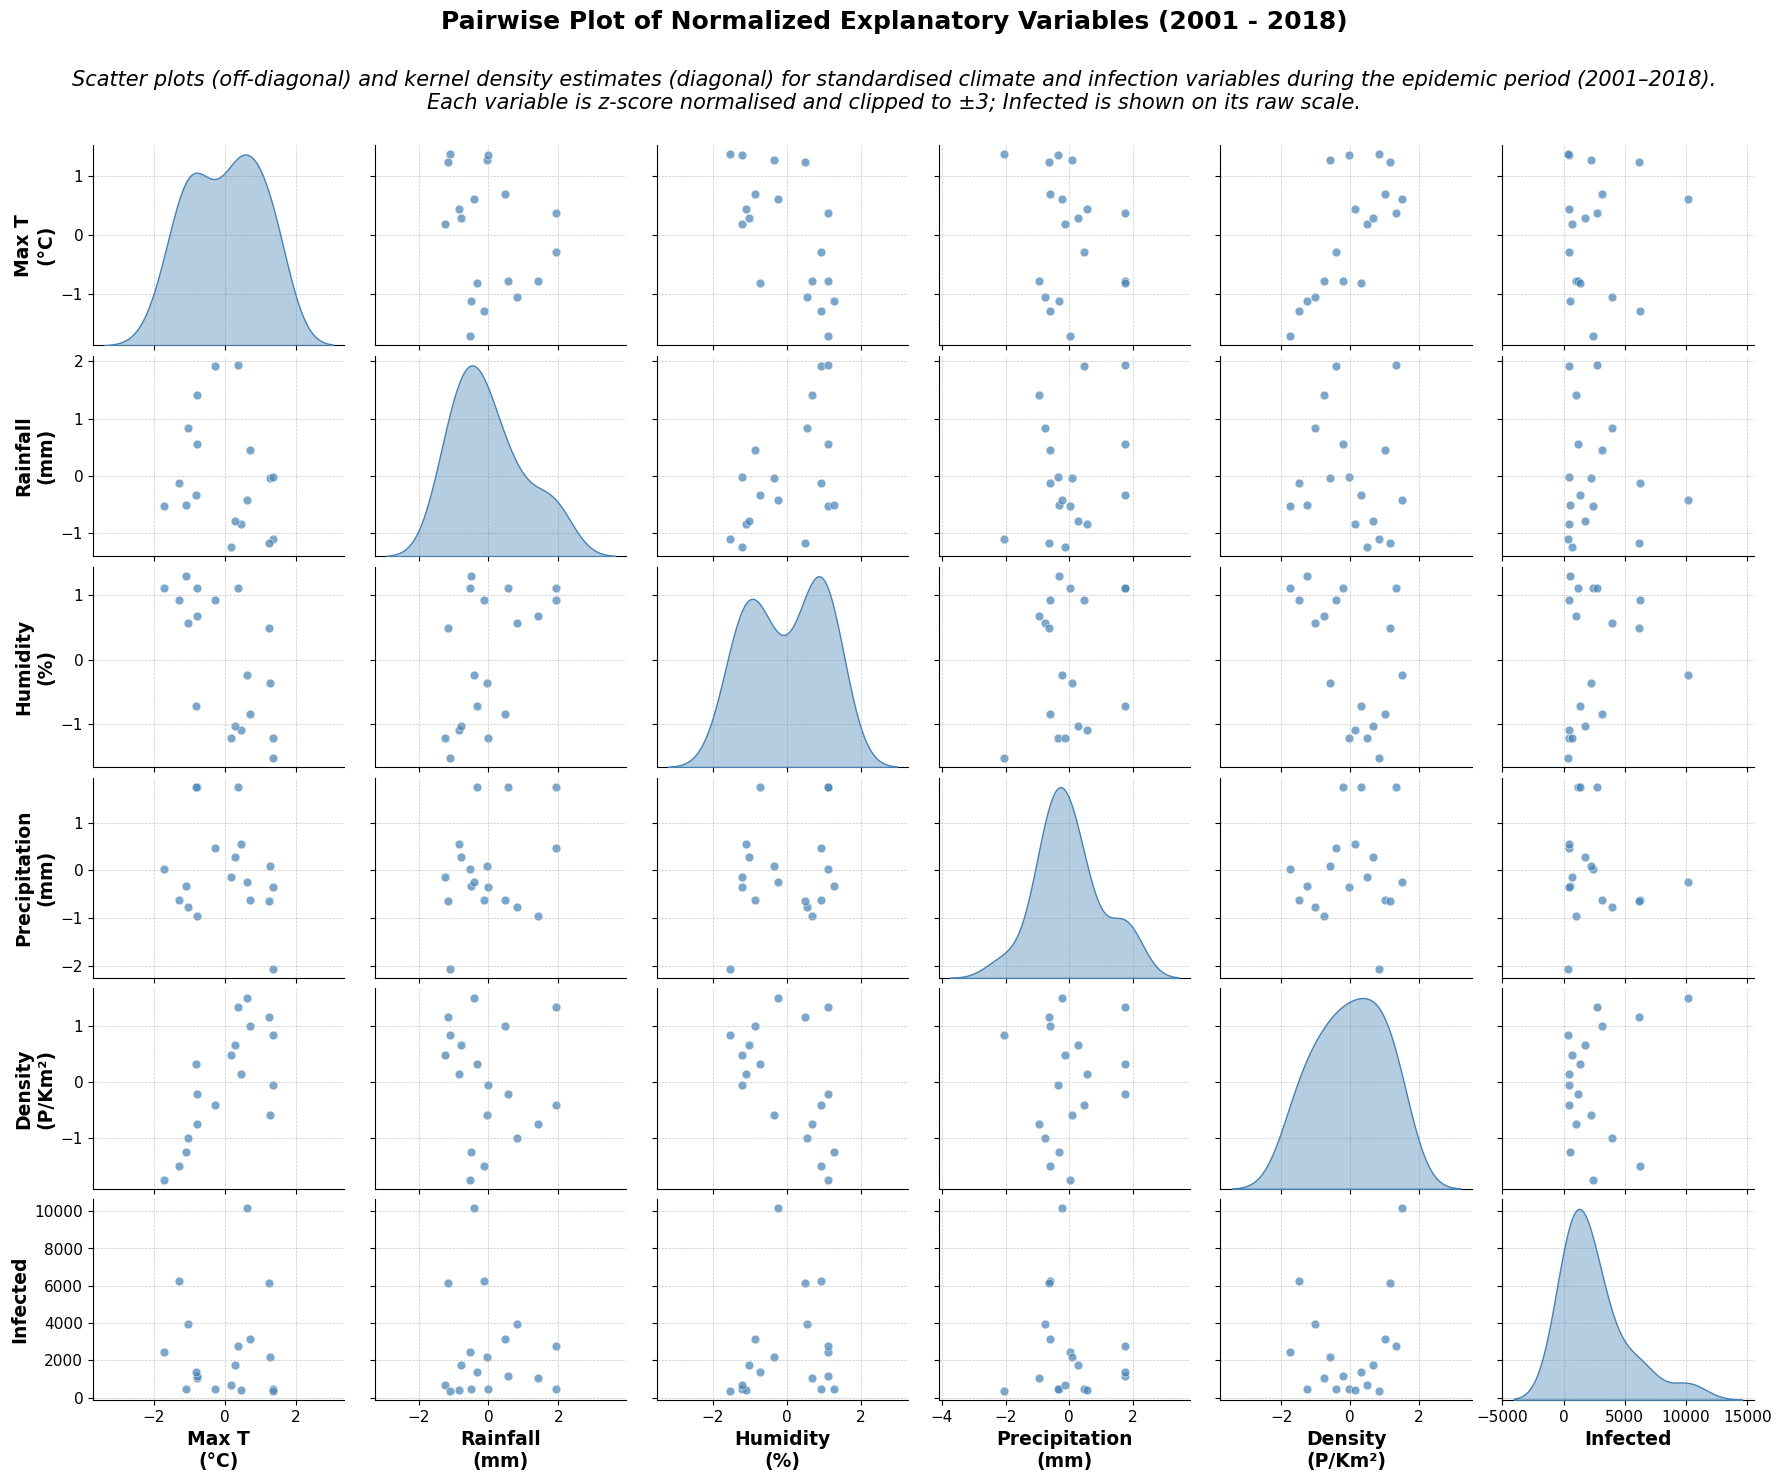

Saved: figure6a_pairplot_epidemic.png


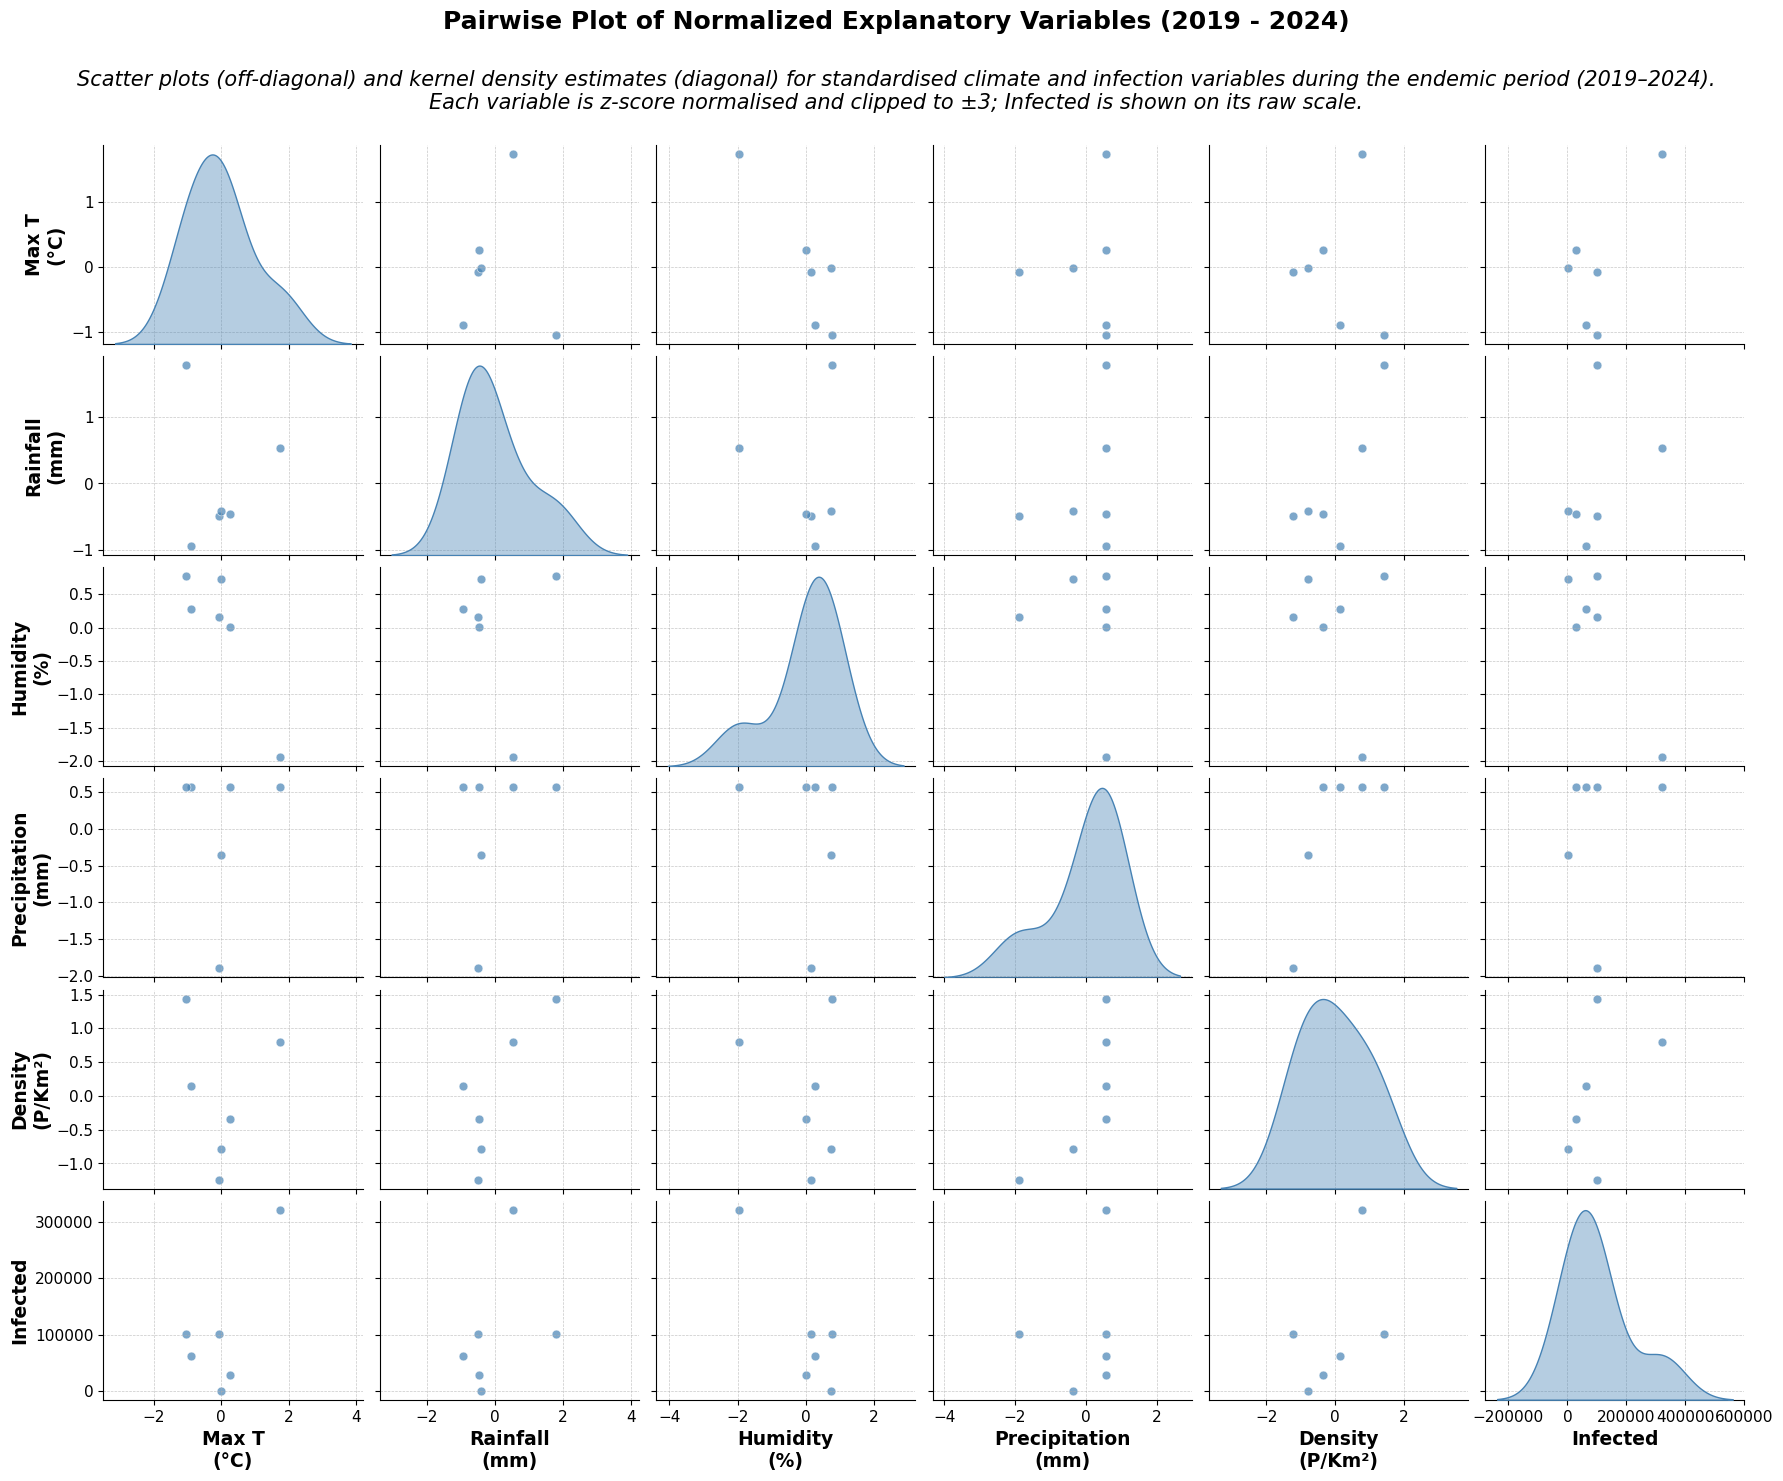

Saved: figure6b_pairplot_endemic.png


In [5]:
"""
Figure 6: Pairwise plot of normalised explanatory variables (2001–2024)

Two separate pairplots — (a) epidemic 2001-2018, (b) endemic 2019-2024 —
saved sequentially. Matches document layout: KDE diagonal, no hue,
subset of variables: Tmax, Rainfall, Relative Humidity, Precipitation,
Population Density, Infected.

Normalisation matches your original code:
  z-score standardisation → clip ±3 → add back Infected raw
"""

import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import pandas as pd

# ── Load data ──────────────────────────────────────────────────────────────────
data = pd.read_excel("./data/Dengue_2001-2024.xlsx")
data_epidemic = data[data['Year'] <= 2018].copy()
data_endemic  = data[data['Year'] >  2018].copy()

# ── Feature columns — subset matching document ─────────────────────────────────
feature_cols = [
    "Tmax", "Rainfall", "Relative Humidity",
    "Precipitation", "Population Density",
]

# ── Axis label map ─────────────────────────────────────────────────────────────
axis_label_map = {
    "Tmax":               "Max T\n(°C)",
    "Rainfall":           "Rainfall\n(mm)",
    "Relative Humidity":  "Humidity\n(%)",
    "Precipitation":      "Precipitation\n(mm)",
    "Population Density": "Density\n(P/Km²)",
    "Infected":           "Infected",
}

def make_normalized(df):
    """Z-score + clip ±3 + re-attach raw Infected — matches your original code."""
    norm = df[feature_cols].apply(pd.to_numeric)
    norm = (norm - norm.mean()) / norm.std()
    norm = norm.clip(lower=-3, upper=3)
    norm["Infected"] = df["Infected"].values
    return norm

def apply_labels(pairplot):
    """Rename axis labels and apply font styling — matches your original code."""
    for ax_row in pairplot.axes:
        for ax in ax_row:
            if ax:
                x_label = ax.get_xlabel()
                y_label = ax.get_ylabel()
                if x_label in axis_label_map:
                    ax.set_xlabel(axis_label_map[x_label])
                if y_label in axis_label_map:
                    ax.set_ylabel(axis_label_map[y_label])
    for ax in pairplot.axes.flatten():
        if ax:
            ax.set_xlabel(ax.get_xlabel(), fontsize=13.5, fontweight='bold')
            ax.set_ylabel(ax.get_ylabel(), fontsize=13.5, fontweight='bold')
            ax.tick_params(axis='both', labelsize=11)

def make_pairplot(df, period_label, subtitle, filename):
    norm = make_normalized(df)

    pp = sns.pairplot(
        norm,
        kind='scatter',
        diag_kind='kde',
        height=2.5,
        aspect=1.2,
        plot_kws={'alpha': 0.7, 's': 40, 'color': 'steelblue'},
        diag_kws={'color': 'steelblue', 'fill': True, 'alpha': 0.4},
    )
    # Turn grid ON for all axes
    for ax in pp.axes.flatten():
        if ax:
            ax.grid(True, linestyle='--', linewidth=0.5, alpha=0.7)

    apply_labels(pp)

    # Use subplots_adjust to reserve space at the top for title + subtitle
    pp.figure.subplots_adjust(top=0.88)

    # Main title — placed inside the reserved top space
    pp.figure.suptitle(
        period_label,
        fontsize=18, fontweight='bold', y=0.97
    )
    # Explanatory subtitle
    pp.figure.text(
        0.5, 0.93, subtitle,
        ha='center', va='top', fontsize=15, style='italic',
        wrap=True
    )

    pp.figure.savefig(filename, dpi=300, bbox_inches='tight')
    plt.show()
    print(f"Saved: {filename}")

# ── Panel (a): Epidemic 2001–2018 ─────────────────────────────────────────────
make_pairplot(
    data_epidemic,
    period_label="Pairwise Plot of Normalized Explanatory Variables (2001 - 2018)",
    subtitle=(
        "Scatter plots (off-diagonal) and kernel density estimates (diagonal) for "
        "standardised climate and infection variables during the epidemic period (2001–2018).\n"
        "Each variable is z-score normalised and clipped to ±3; Infected is shown on its raw scale."
    ),
    filename="figure6a_pairplot_epidemic.png"
)

# ── Panel (b): Endemic 2019–2024 ──────────────────────────────────────────────
make_pairplot(
    data_endemic,
    period_label="Pairwise Plot of Normalized Explanatory Variables (2019 - 2024)",
    subtitle=(
        "Scatter plots (off-diagonal) and kernel density estimates (diagonal) for "
        "standardised climate and infection variables during the endemic period (2019–2024).\n"
        "Each variable is z-score normalised and clipped to ±3; Infected is shown on its raw scale."
    ),
    filename="figure6b_pairplot_endemic.png"
)